# Customer Intelligence System
## End-to-End: Churn Classification + Behavioral Clustering with Ensemble Learning

**Internship:** Celebal Technologies - Data Science Internship
**Author:** Om Mardane

### Objective
Build an end-to-end customer intelligence pipeline on real bank customer data:
1. **Cluster** customers into behavioral segments using **K-Means** and **DBSCAN** (unsupervised,
   based on financial/demographic behavior - no churn label used)
2. **Classify** which customers are likely to churn using **Random Forest** and **XGBoost**
   (**ensemble learning**), using the discovered segment as an engineered feature
3. Tune both classifiers for **optimized predictive performance** and compare them
4. Combine clustering + classification into **actionable, segment-level retention insights**

**Dataset:** Bank Customer Churn Modelling data (10,000 customers, real churn outcomes)


## 1) Install & Import Libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
np.random.seed(42)

## 2) Load the Dataset

In [3]:
df = pd.read_csv('Churn_Modelling.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3) Quick Inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [6]:
df['Exited'].value_counts(normalize=True).rename('proportion')

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## 4) Data Cleaning

`RowNumber`, `CustomerId`, and `Surname` are identifiers with no predictive value and
are dropped. The data has no missing values or duplicates to handle in this dataset,
but we check anyway.

In [7]:
print('Duplicate rows:', df.duplicated().sum())
print('Missing values:\n', df.isna().sum())

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

Duplicate rows: 0
Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 5) Exploratory Data Analysis

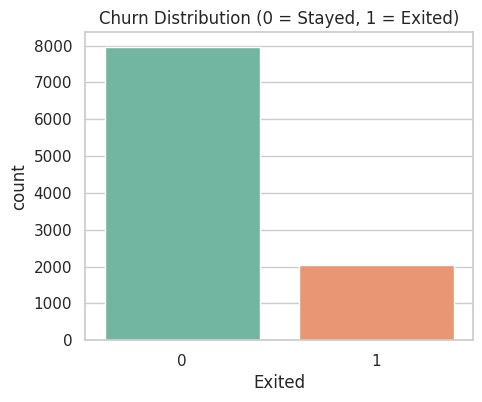

Exited
0    7963
1    2037
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Churn Distribution (0 = Stayed, 1 = Exited)')
plt.show()
print(df['Exited'].value_counts())

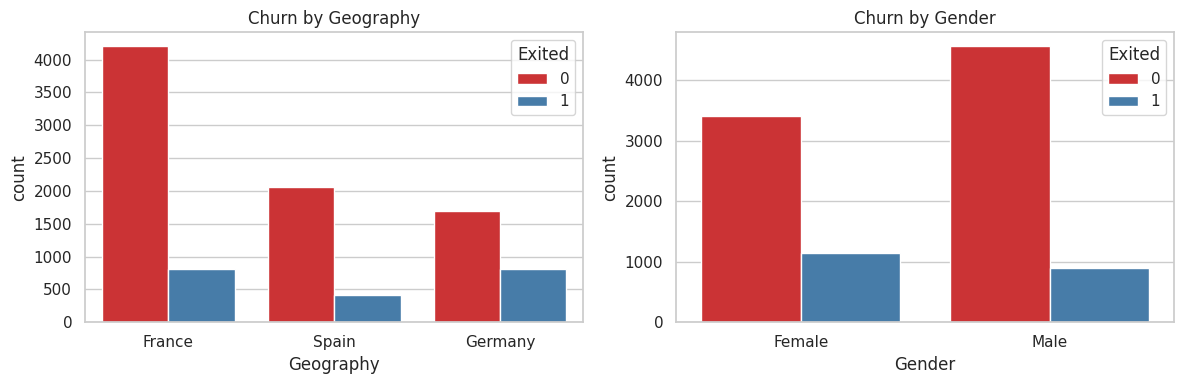

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Churn by Geography')
sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Churn by Gender')
plt.tight_layout()
plt.show()

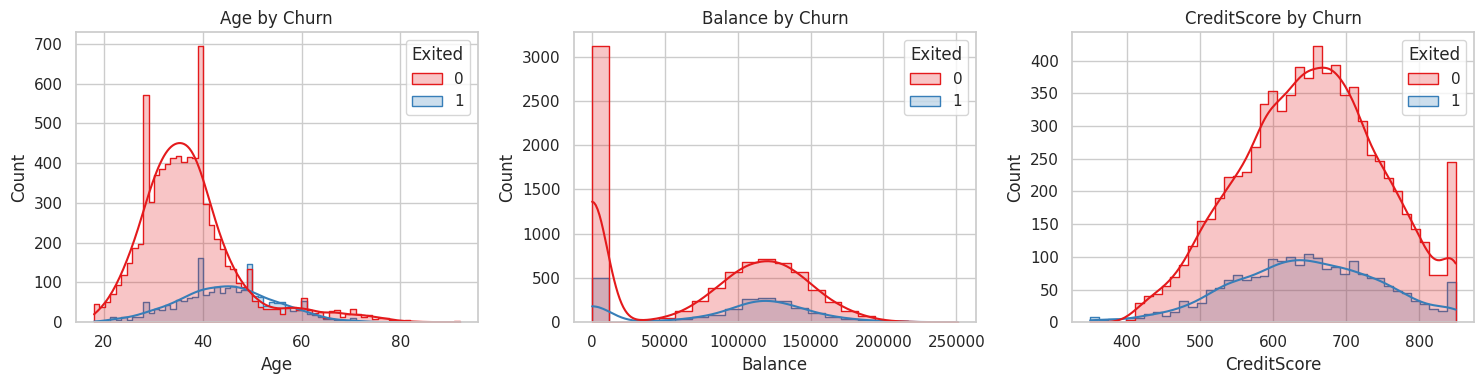

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Age', 'Balance', 'CreditScore']):
    sns.histplot(data=df, x=col, hue='Exited', kde=True, ax=ax, palette='Set1', element='step')
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

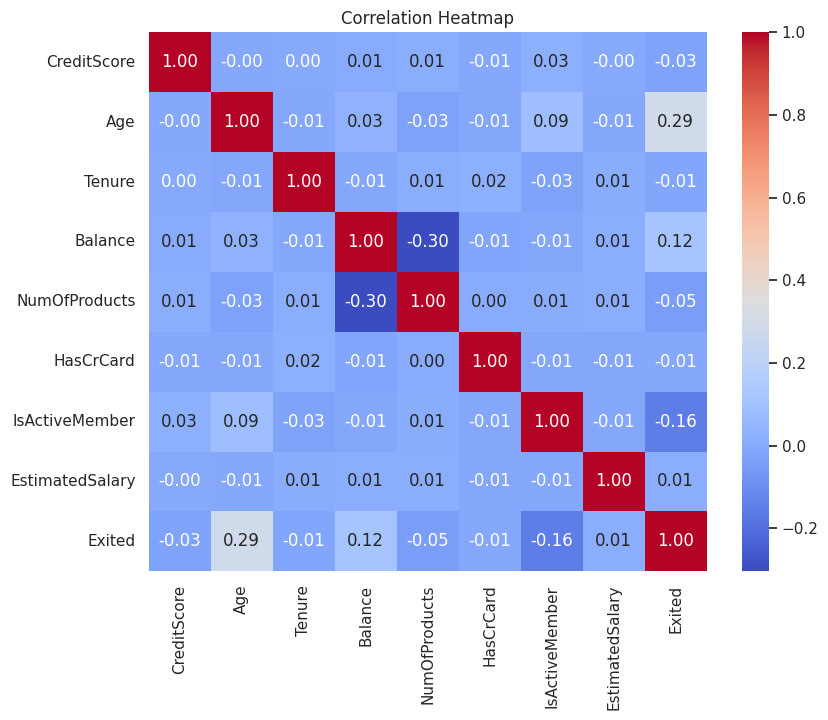

In [11]:
plt.figure(figsize=(9,7))
numeric_for_corr = df.select_dtypes(include=np.number)
sns.heatmap(numeric_for_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 6) Feature Engineering

- `Gender` -> binary encoded
- `Geography` -> one-hot encoded
- Behavioral/financial columns are scaled for clustering


In [12]:
df['Gender_encoded'] = LabelEncoder().fit_transform(df['Gender'])  # Female=0, Male=1
df = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=True)

cluster_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                     'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
X_cluster_scaled.shape

(10000, 8)

## 7) K-Means: Behavioral Segmentation

Clustering is run **without the churn label** - this discovers natural customer
segments purely from financial/demographic behavior. We then check churn rate per
segment afterward as a diagnostic, not as an input.

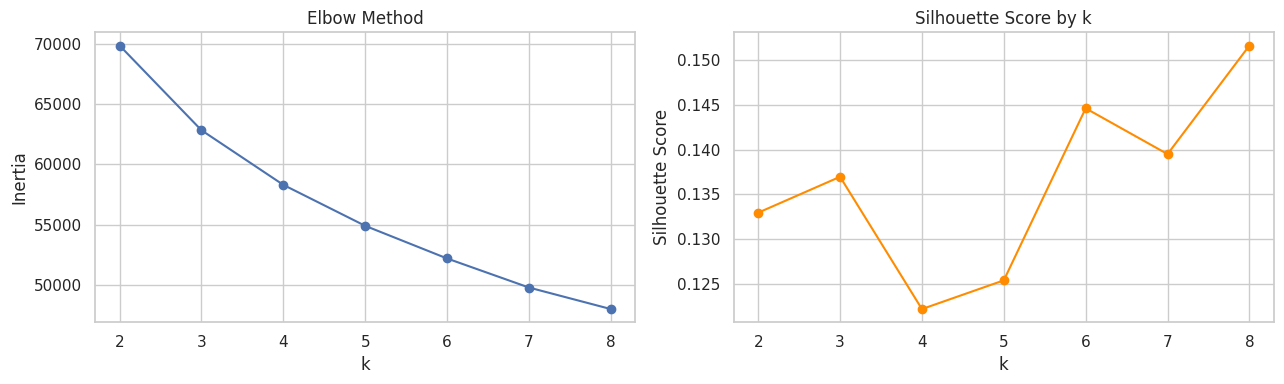

Best k by silhouette score: 8


In [13]:
inertias, sil_scores = [], []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_cluster_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_values), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(sil_scores))]
print('Best k by silhouette score:', best_k)

In [14]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_cluster_scaled)

print('Final Silhouette Score:', silhouette_score(X_cluster_scaled, df['segment']))
df['segment'].value_counts().sort_index()

Final Silhouette Score: 0.151614011703047


segment
0    1272
1    1807
2    1868
3     761
4    1004
5     979
6     829
7    1480
Name: count, dtype: int64

## 8) DBSCAN: Alternative Clustering Method

In [15]:
dbscan = DBSCAN(eps=1.3, min_samples=15)
df['dbscan_segment'] = dbscan.fit_predict(X_cluster_scaled)

n_clusters_db = len(set(df['dbscan_segment'])) - (1 if -1 in df['dbscan_segment'].values else 0)
n_noise = int((df['dbscan_segment'] == -1).sum())
print(f'DBSCAN found {n_clusters_db} clusters and {n_noise} noise point(s)')
df['dbscan_segment'].value_counts().sort_index()

DBSCAN found 8 clusters and 754 noise point(s)


dbscan_segment
-1     754
 0    1710
 1     702
 2     605
 3    1491
 4    1677
 5     640
 6     642
 7    1779
Name: count, dtype: int64

## 9) PCA Visualization of K-Means Segments

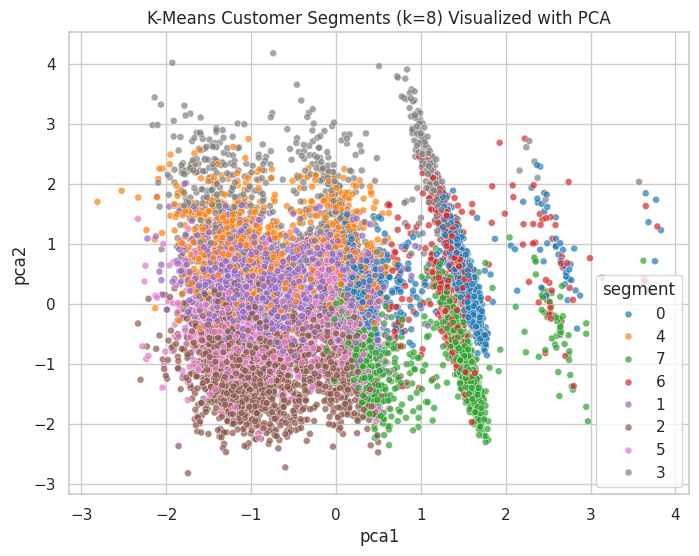

Explained variance ratio: [0.164 0.137] (total: 30.15%)


In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

viz = pd.DataFrame({'pca1': X_pca[:,0], 'pca2': X_pca[:,1], 'segment': df['segment'].astype(str)})

plt.figure(figsize=(8,6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='segment', palette='tab10', s=25, alpha=0.7)
plt.title(f'K-Means Customer Segments (k={best_k}) Visualized with PCA')
plt.show()

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)} '
      f'(total: {pca.explained_variance_ratio_.sum():.2%})')

## 10) Segment Profiling + Churn Rate per Segment

This is where clustering becomes actionable: which behavioral segments actually churn the most?

In [17]:
profile = df.groupby('segment')[cluster_features].mean().round(1)
profile['count'] = df['segment'].value_counts().sort_index()
profile['churn_rate'] = (df.groupby('segment')['Exited'].mean() * 100).round(1)
profile.sort_values('churn_rate', ascending=False)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,count,churn_rate
segment,,,,,,,,,,
5,650.7,38.3,5.0,106271.0,1.3,0.0,0.0,100887.1,979,29.8
3,653.9,62.9,5.0,72441.5,1.5,0.8,0.9,94288.2,761,29.3
2,645.1,37.9,5.2,124659.0,1.3,1.0,0.0,102906.4,1868,29.2
7,649.5,36.5,5.1,16891.0,1.9,1.0,0.0,98796.4,1480,21.0
4,655.0,38.2,4.7,106804.0,1.3,0.0,1.0,102582.8,1004,18.8
1,655.3,35.7,4.9,122452.6,1.3,1.0,1.0,99081.8,1807,13.0
6,646.4,36.7,5.1,9958.9,2.1,0.0,0.5,101075.7,829,12.8
0,649.9,36.0,5.1,8703.5,1.9,1.0,1.0,99140.7,1272,10.6


In [18]:
overall_churn = df['Exited'].mean() * 100
print(f'Overall churn rate: {overall_churn:.1f}%\n')

print('=== Automated Segment Insights ===\n')
for s in profile.index:
    row = profile.loc[s]
    flag = 'HIGH RISK' if row['churn_rate'] > overall_churn * 1.2 else ('LOW RISK' if row['churn_rate'] < overall_churn * 0.8 else 'AVERAGE')
    print(f"Segment {s} | {int(row['count'])} customers | Churn Rate: {row['churn_rate']}% [{flag}] | "
          f"Avg Age: {row['Age']} | Avg Balance: {row['Balance']:.0f} | Avg Products: {row['NumOfProducts']:.1f}")

highest_risk = profile['churn_rate'].idxmax()
lowest_risk = profile['churn_rate'].idxmin()
print(f"\n>> Segment {highest_risk} has the highest churn rate ({profile.loc[highest_risk,'churn_rate']}%) "
      f"-> prioritize this segment for retention campaigns.")
print(f">> Segment {lowest_risk} has the lowest churn rate ({profile.loc[lowest_risk,'churn_rate']}%) "
      f"-> stable segment, good candidates for upsell/cross-sell.")

Overall churn rate: 20.4%

=== Automated Segment Insights ===

Segment 0 | 1272 customers | Churn Rate: 10.6% [LOW RISK] | Avg Age: 36.0 | Avg Balance: 8704 | Avg Products: 1.9
Segment 1 | 1807 customers | Churn Rate: 13.0% [LOW RISK] | Avg Age: 35.7 | Avg Balance: 122453 | Avg Products: 1.3
Segment 2 | 1868 customers | Churn Rate: 29.2% [HIGH RISK] | Avg Age: 37.9 | Avg Balance: 124659 | Avg Products: 1.3
Segment 3 | 761 customers | Churn Rate: 29.3% [HIGH RISK] | Avg Age: 62.9 | Avg Balance: 72442 | Avg Products: 1.5
Segment 4 | 1004 customers | Churn Rate: 18.8% [AVERAGE] | Avg Age: 38.2 | Avg Balance: 106804 | Avg Products: 1.3
Segment 5 | 979 customers | Churn Rate: 29.8% [HIGH RISK] | Avg Age: 38.3 | Avg Balance: 106271 | Avg Products: 1.3
Segment 6 | 829 customers | Churn Rate: 12.8% [LOW RISK] | Avg Age: 36.7 | Avg Balance: 9959 | Avg Products: 2.1
Segment 7 | 1480 customers | Churn Rate: 21.0% [AVERAGE] | Avg Age: 36.5 | Avg Balance: 16891 | Avg Products: 1.9

>> Segment 5 has

---
## 11) Churn Classification

Now we build supervised classifiers to **predict which individual customers will
churn**, using the original features *plus* the discovered segment as an engineered
feature (a real technique: unsupervised structure feeding into a supervised model).
Churn is imbalanced (~20% positive class), so class weighting and F1/ROC-AUC are
used instead of relying on accuracy alone.

In [19]:
geo_cols = [c for c in df.columns if c.startswith('Geo_')]
clf_features = cluster_features + ['Gender_encoded'] + geo_cols + ['segment']

X = pd.get_dummies(df[clf_features], columns=['segment'], prefix='seg')
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])
print('Train churn rate:', y_train.mean().round(3), '| Test churn rate:', y_test.mean().round(3))

Train size: 8000 | Test size: 2000
Train churn rate: 0.204 | Test churn rate: 0.204


## 12) Random Forest Classifier (with Hyperparameter Tuning)

In [20]:
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    rf_param_grid, cv=5, scoring='f1', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

print('Best RF params:', rf_grid.best_params_)
print('RF Accuracy:', round(accuracy_score(y_test, rf_pred), 4))
print('RF ROC-AUC:', round(roc_auc_score(y_test, rf_proba), 4))
print('\n', classification_report(y_test, rf_pred))

Best RF params: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 300}
RF Accuracy: 0.8195
RF ROC-AUC: 0.864

               precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.69      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



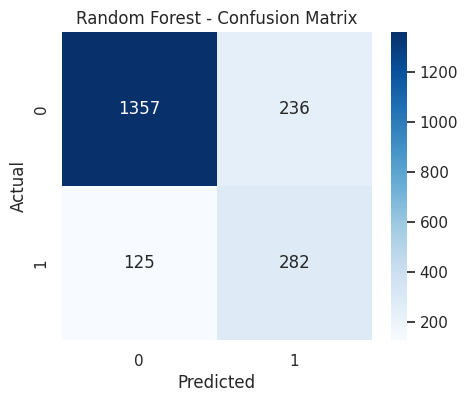

In [21]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

## 13) XGBoost Classifier (with Hyperparameter Tuning)

In [22]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    xgb_param_grid, cv=5, scoring='f1', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

print('Best XGB params:', xgb_grid.best_params_)
print('XGBoost Accuracy:', round(accuracy_score(y_test, xgb_pred), 4))
print('XGBoost ROC-AUC:', round(roc_auc_score(y_test, xgb_proba), 4))
print('\n', classification_report(y_test, xgb_pred))

Best XGB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost Accuracy: 0.8115
XGBoost ROC-AUC: 0.8568

               precision    recall  f1-score   support

           0       0.92      0.83      0.88      1593
           1       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



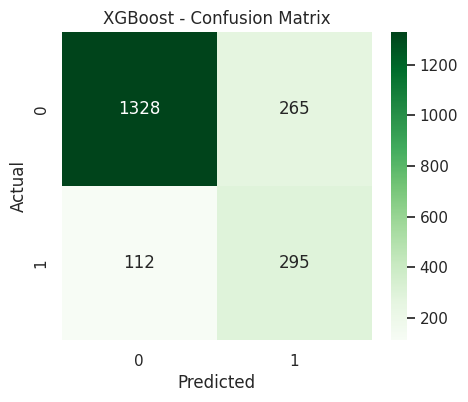

In [23]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

## 14) Ensemble Model Comparison

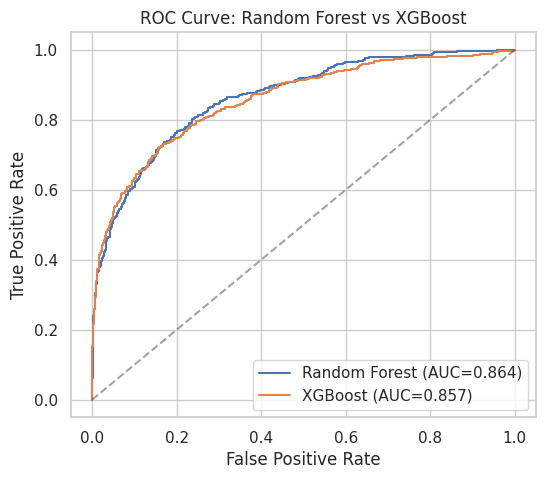

In [24]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_proba):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_proba):.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest vs XGBoost')
plt.legend()
plt.show()

In [25]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    'F1 (churn class)': [f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    'ROC-AUC': [roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, xgb_proba)]
}).round(4)
comparison

,Model,Accuracy,F1 (churn class),ROC-AUC
0,Random Forest,0.8195,0.6097,0.8640
1,XGBoost,0.8115,0.6101,0.8568


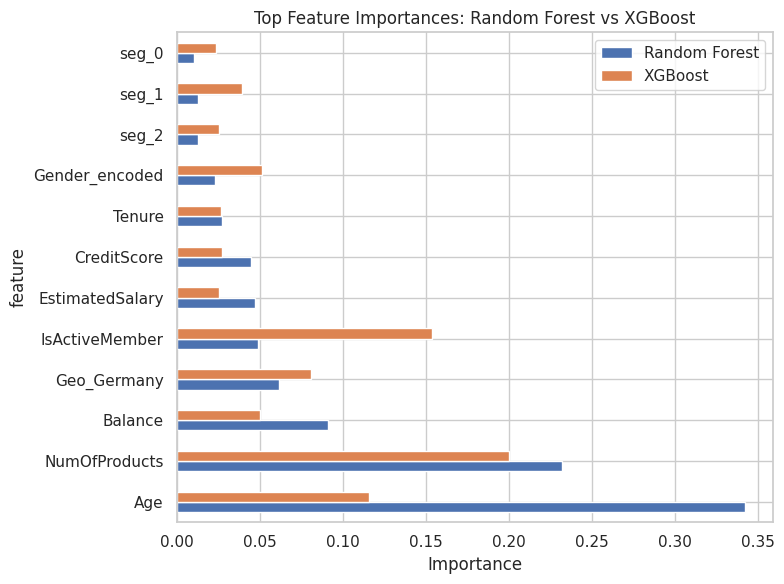

In [26]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'Random Forest': rf_best.feature_importances_,
    'XGBoost': xgb_best.feature_importances_
}).set_index('feature').sort_values('Random Forest', ascending=False).head(12)

importance_df.plot(kind='barh', figsize=(8,6))
plt.title('Top Feature Importances: Random Forest vs XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 15) Conclusion

This notebook implements a complete **Customer Intelligence System** on real bank
churn data:

- **Clustering (K-Means, DBSCAN + PCA):** discovered behavioral customer segments
  from credit score, age, balance, product usage, and activity - independent of the
  churn label.
- **Segment-level churn diagnostics:** quantified churn rate per segment, flagging
  which behavioral groups are highest-risk vs. stable.
- **Classification (Random Forest, XGBoost):** predicted individual customer churn
  using engineered features, including the discovered segment as a feature -
  connecting the unsupervised and supervised stages into one pipeline.
- **Hyperparameter tuning (GridSearchCV)** on both models for optimized predictive
  performance, evaluated with F1 and ROC-AUC given class imbalance.
- **Ensemble model comparison** via ROC curves, F1, and feature importances.

Together, this matches the resume line: *"Developed an end-to-end Customer
Intelligence System using classification, ensemble learning (Random Forest,
XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive
performance and actionable customer segmentation insights."*
